In [ ]:
from groq import Groq
import pandas as pd
from tqdm import tqdm
import time
import matplotlib.pyplot as plt

# ============================================================
# CONFIGURATION
# ============================================================

GROQ_API_KEY = "my_api_key"

# ============================================================
# CHARGER LES DONNÉES
# ============================================================

df = pd.read_csv('/home/ensai/Cours/PFE/Topic-modeling-with-NLP/llm_local_clustering.csv')

print(f"📊 Dataset chargé: {len(df)} propositions")
print(f"📋 Thèmes uniques: {df['theme'].nunique()}")
print(f"\nDistribution des thèmes:")
print(df['theme'].value_counts())

📊 Dataset chargé: 5554 propositions
📋 Thèmes uniques: 20

Distribution des thèmes:
theme
Environmental Protection                        1201
Conservation of Biodiversity                     648
Animal Welfare                                   557
Biomass and Forest Management                    550
Citizen Engagement and Education                 439
Waste Reduction and Recycling                    419
Urban Planning and Green Spaces                  415
Sustainable Agriculture                          386
Water Conservation                               199
Sustainable Transportation                       163
Pesticide Reduction                              118
Protected Areas and Nature Reserves              109
Insect Protection                                 80
Renewable Energy and Sustainable Development      79
Climate Change Mitigation                         59
Biodiversity and Ecological Corridors             50
Ecosystem Restoration                             29
Habitat Pr

In [8]:
def llm_judge_proposition_with_theme(proposition, assigned_theme, api_key):
    """
    Évalue si une proposition correspond au thème assigné.
    
    Returns:
        dict: {'score': 0 ou 1, 'suggested_theme': str ou None}
    """
    client = Groq(api_key=api_key)
    
    prompt = f"""Thème assigné: {assigned_theme}

Proposition: {proposition}

Tâche:
1. La proposition correspond-elle au thème assigné? (1=oui, 0=non)
2. Si non (0), quel serait le thème approprié? (2-5 mots)

Réponds au format: <score>|<thème suggéré si score=0, sinon vide>

Exemples:
- 1|
- 0|Infrastructure et transports
- 0|Santé publique"""

    try:
        response = client.chat.completions.create(
            messages=[
                {"role": "system", "content": "Tu réponds au format exact: score|thème"},
                {"role": "user", "content": prompt}
            ],
            model="llama-3.3-70b-versatile",
            temperature=0,
            max_tokens=50,
        )
        
        answer = response.choices[0].message.content.strip()
        
        parts = answer.split('|')
        score = 1 if '1' in parts[0] else 0
        suggested_theme = parts[1].strip() if len(parts) > 1 and parts[1].strip() else None
        
        return {
            'score': score,
            'suggested_theme': suggested_theme if score == 0 else None
        }
        
    except Exception as e:
        print(f"Erreur: {e}")
        return {'score': None, 'suggested_theme': None}

In [9]:
def evaluate_df(df, api_key, batch_delay=1):
    """
    Applique le LLM judge directement sur votre DataFrame.
    Remplit les colonnes 'judge_score' et 'judge_suggestion'.
    
    Args:
        df: DataFrame avec colonnes 'Proposition', 'theme', 'judge_score', 'judge_suggestion'
        api_key: Clé API Groq
        batch_delay: Délai entre les requêtes pour éviter le rate limit
    
    Returns:
        DataFrame avec les colonnes 'judge_score' et 'judge_suggestion' remplies
    """
    df = df.copy()
    
    # Filtrer les propositions pas encore évaluées
    to_evaluate = df[df['judge_score'].isna()].index
    
    print(f"\n📊 Total propositions: {len(df)}")
    print(f"✅ Déjà évaluées: {df['judge_score'].notna().sum()}")
    print(f"🔄 À évaluer: {len(to_evaluate)}")
    
    for i, idx in enumerate(tqdm(to_evaluate, desc="Évaluation")):
        proposition = df.loc[idx, 'Proposition']
        theme = df.loc[idx, 'theme']
        
        judgment = llm_judge_proposition_with_theme(proposition, theme, api_key)
        
        if judgment['score'] is not None:
            df.loc[idx, 'judge_score'] = judgment['score']
            df.loc[idx, 'judge_suggestion'] = judgment['suggested_theme']
        
        # Délai pour éviter rate limit
        if (i + 1) % 10 == 0:
            time.sleep(batch_delay)
        
        # Sauvegarder tous les 100 évaluations (checkpoint)
        if (i + 1) % 100 == 0:
            df.to_csv('evaluation_checkpoint.csv', index=False, encoding='utf-8')
    
    return df

In [10]:
def analyze_results_with_suggestions(df):
    """
    Analyse les résultats par theme.
    
    Returns:
        tuple: (cluster_stats DataFrame, non_pertinentes DataFrame)
    """
    # Stats par theme
    cluster_stats = df.groupby(['cluster_id', 'theme']).agg(
        taux_pertinence=('judge_score', 'mean'),
        nb_pertinentes=('judge_score', 'sum'),
        nb_total=('judge_score', 'count')
    ).reset_index()
    
    cluster_stats['taux_pertinence'] = (cluster_stats['taux_pertinence'] * 100).round(1)
    
    print("\n" + "="*80)
    print("📊 RÉSULTATS PAR CLUSTER/THEME")
    print("="*80)
    print(cluster_stats.to_string(index=False))
    
    # Non pertinentes
    non_pertinentes = df[df['judge_score'] == 0].copy()
    
    if len(non_pertinentes) > 0:
        print("\n" + "="*80)
        print("❌ PROPOSITIONS NON PERTINENTES AVEC THÈMES SUGGÉRÉS")
        print("="*80)
        
        for theme in sorted(non_pertinentes['theme'].unique()):
            theme_data = non_pertinentes[non_pertinentes['theme'] == theme]
            
            print(f"\n🏷️  THEME: {theme}")
            print(f"   {len(theme_data)} propositions non pertinentes")
            print("-" * 80)
            
            for idx, row in theme_data.head(5).iterrows():
                prop_preview = row['Proposition'][:100] + "..." if len(row['Proposition']) > 100 else row['Proposition']
                print(f"   • {prop_preview}")
                print(f"     ➜ Thème suggéré: {row['judge_suggestion']}")
                print()
    
    # Thèmes suggérés les plus fréquents
    if len(non_pertinentes) > 0:
        print("\n" + "="*80)
        print("📈 THÈMES SUGGÉRÉS LES PLUS FRÉQUENTS")
        print("="*80)
        theme_counts = non_pertinentes['judge_suggestion'].value_counts().head(10)
        for theme, count in theme_counts.items():
            print(f"   • {theme}: {count} propositions")
    
    # Stats globales
    print("\n" + "="*80)
    print("📈 STATISTIQUES GLOBALES")
    print("="*80)
    taux_global = df['judge_score'].mean() * 100
    print(f"Taux de pertinence global: {taux_global:.1f}%")
    print(f"Total propositions évaluées: {df['judge_score'].notna().sum()}")
    print(f"Propositions pertinentes: {int(df['judge_score'].sum())}")
    print(f"Propositions non pertinentes: {int((df['judge_score'] == 0).sum())}")
    
    return cluster_stats, non_pertinentes

In [11]:
def visualize_results(cluster_stats):
    """Visualise les résultats par cluster"""
    fig, ax = plt.subplots(figsize=(14, 7))
    
    cluster_stats_sorted = cluster_stats.sort_values('cluster_id')
    colors = ['#2ecc71' if x >= 80 else '#e74c3c' for x in cluster_stats_sorted['taux_pertinence']]
    
    bars = ax.bar(range(len(cluster_stats_sorted)), cluster_stats_sorted['taux_pertinence'], 
                  color=colors, alpha=0.7, edgecolor='black')
    
    ax.axhline(y=80, color='red', linestyle='--', linewidth=2, label='Seuil 80%')
    
    # Labels
    ax.set_xticks(range(len(cluster_stats_sorted)))
    ax.set_xticklabels(
        [f"C{row['cluster_id']}\n{row['theme'][:20]}" for _, row in cluster_stats_sorted.iterrows()],
        rotation=45, ha='right', fontsize=8
    )
    
    # Valeurs sur les barres
    for bar, val in zip(bars, cluster_stats_sorted['taux_pertinence']):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{val:.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    ax.set_ylabel('Taux de pertinence (%)', fontsize=12, fontweight='bold')
    ax.set_title('LLM as Judge - Pertinence par cluster/theme (150 samples)', fontsize=14, fontweight='bold')
    ax.set_ylim(0, 110)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('llm_judge_results.png', dpi=300)
    print("\n📊 Graphique sauvegardé: 'llm_judge_results.png'")
    plt.show()

In [12]:
def analyze_suggested_themes(df):
    """Analyse les patterns de réassignation"""
    non_pert = df[df['judge_score'] == 0]
    
    if len(non_pert) == 0:
        print("\n✅ Aucune proposition non pertinente détectée!")
        return
    
    print("\n" + "="*80)
    print("🔍 ANALYSE DES RÉASSIGNATIONS SUGGÉRÉES")
    print("="*80)
    
    for theme in sorted(non_pert['theme'].unique()):
        theme_data = non_pert[non_pert['theme'] == theme]
        
        print(f"\n📦 Theme: {theme}")
        print(f"   {len(theme_data)} propositions mal classées")
        
        top_themes = theme_data['judge_suggestion'].value_counts().head(3)
        if len(top_themes) > 0:
            print("   Top 3 thèmes suggérés:")
            for suggested, count in top_themes.items():
                pct = (count / len(theme_data)) * 100
                print(f"     • {suggested}: {count} ({pct:.1f}%)")

📊 Dataset total: 5554 propositions
📊 Échantillon: 150 propositions
📋 Thèmes dans l'échantillon: 16

📊 Total propositions: 150
✅ Déjà évaluées: 3
🔄 À évaluer: 147


Évaluation: 100%|██████████| 147/147 [04:49<00:00,  1.97s/it]



📊 RÉSULTATS PAR CLUSTER/THEME
 cluster_id                                        theme  taux_pertinence  nb_pertinentes  nb_total
          0                               Animal Welfare            100.0             8.0         8
          2                Biomass and Forest Management             94.1            16.0        17
          3             Citizen Engagement and Education             93.3            14.0        15
          4                    Climate Change Mitigation             50.0             1.0         2
          5                 Conservation of Biodiversity            100.0            24.0        24
          8                     Environmental Protection             77.8            21.0        27
          9                         Habitat Preservation            100.0             2.0         2
         10                            Insect Protection            100.0             2.0         2
         11                          Pesticide Reduction            1

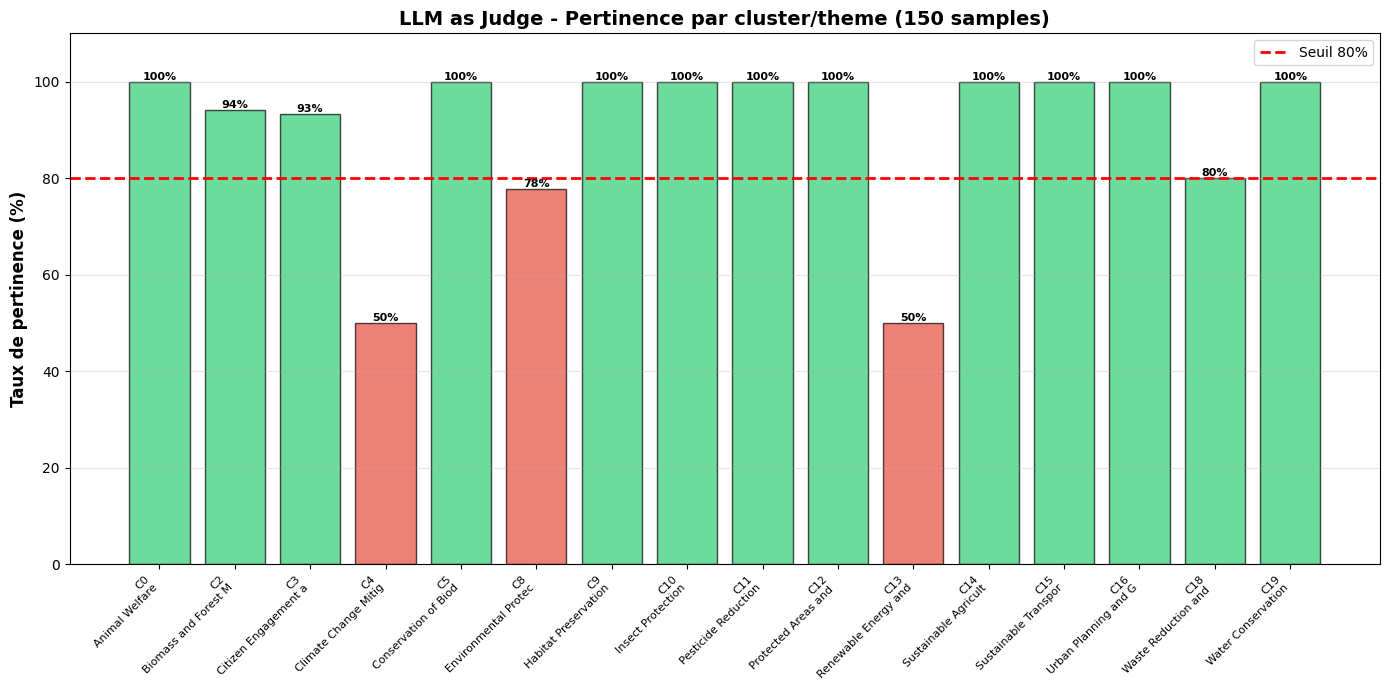


🔍 ANALYSE DES RÉASSIGNATIONS SUGGÉRÉES

📦 Theme: Biomass and Forest Management
   1 propositions mal classées
   Top 3 thèmes suggérés:
     • Bâtiment et construction: 1 (100.0%)

📦 Theme: Citizen Engagement and Education
   1 propositions mal classées
   Top 3 thèmes suggérés:
     • Environnement et biodiversité: 1 (100.0%)

📦 Theme: Climate Change Mitigation
   1 propositions mal classées
   Top 3 thèmes suggérés:
     • Santé et bien-être: 1 (100.0%)

📦 Theme: Environmental Protection
   6 propositions mal classées
   Top 3 thèmes suggérés:
     • Politique environnementale: 1 (16.7%)
     • Transport et environnement: 1 (16.7%)
     • Santé publique: 1 (16.7%)

📦 Theme: Renewable Energy and Sustainable Development
   1 propositions mal classées
   Top 3 thèmes suggérés:
     • Gouvernance et administration: 1 (100.0%)

📦 Theme: Waste Reduction and Recycling
   3 propositions mal classées
   Top 3 thèmes suggérés:
     • Entretien des espaces verts: 1 (33.3%)
     • Gestion de l'

In [14]:
# ============================================================
# EXÉCUTION COMPLÈTE
# ============================================================

# 1. Échantillonner 150 propositions
df_sample = df.sample(n=150, random_state=42).reset_index(drop=True)

print(f"📊 Dataset total: {len(df)} propositions")
print(f"📊 Échantillon: {len(df_sample)} propositions")
print(f"📋 Thèmes dans l'échantillon: {df_sample['theme'].nunique()}")

# 2. Évaluer
df_evaluated = evaluate_df(
    df=df_sample,
    api_key=GROQ_API_KEY,
    batch_delay=1
)

# 3. Analyser
cluster_stats, non_pertinentes = analyze_results_with_suggestions(df_evaluated)

# 4. Visualiser
visualize_results(cluster_stats)

# 5. Analyser réassignations
analyze_suggested_themes(df_evaluated)

# 6. Sauvegarder
df_evaluated.to_csv('llm_judge_150_samples.csv', index=False, encoding='utf-8')
print("\n💾 Résultats sauvegardés: 'llm_judge_150_samples.csv'")